In [1]:
# =============
# CARGA DE LIBRERIAS

from astropy.io import fits
import gc
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np
import os
import pickle
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [2]:
# =============
# CARGA DE DATASETS

# Definir la clase Dataset
class SpectraDataset(Dataset):
    def __init__(self, dataset_path):
        # Cargamos el diccionario previamente guardado (.pt)
        data = torch.load(dataset_path)
        self.flux = data["flux"]          # Tensor con forma [N, num_points]
        self.wavelength = data["wavelength"]  # Tensor con forma [N, num_points]
        self.redshift = data["redshift"]      # Tensor con forma [N]
    
    def __len__(self):
        return self.flux.shape[0]
    
    def __getitem__(self, idx):
        input_sample = torch.stack([self.flux[idx], self.wavelength[idx]], dim=0)  # [2, num_points]
        target = self.redshift[idx]
        return input_sample, target

# Rutas a los archivos preprocesados
data_dir = "data"
train_dataset_path = os.path.join(data_dir, "train_dataset.pt")
test_dataset_path  = os.path.join(data_dir, "test_dataset.pt")

# Crear los datasets
train_dataset = SpectraDataset(train_dataset_path)
test_dataset  = SpectraDataset(test_dataset_path)

# Crear DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

In [3]:
# =============
# DEFINICIÓN Y CONFIGURACIÓN DEL MODELO

# Configurar dispositivo para GPU si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Número de puntos en cada espectro
num_points = 5000

# Definir el modelo CNN en PyTorch con dropout para regularización
class CNN(nn.Module):
    def __init__(self, num_points):
        super(CNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv1d(in_channels=2, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        # Con 5 capas de max pooling, la dimensión se reduce en un factor de 2^5 = 32
        conv_output_size = num_points // 32
        self.fc_layers = nn.Sequential(
            nn.Linear(256 * conv_output_size, 128),
            nn.ReLU(),
            nn.Dropout(p=0.25),  # Regularización con Dropout
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

# Instanciar el modelo y moverlo a GPU si está disponible
modelCNN = CNN(num_points).to(device)
criterion = nn.L1Loss()
optimizer = optim.Adam(modelCNN.parameters(), lr=0.0001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

print("Modelo configurado correctamente.")

Usando dispositivo: cuda
Modelo configurado correctamente.


In [4]:
# =============
# INICIALIZACIÓN DEL MODELO

num_epochs = 1
for epoch in range(num_epochs):
    modelCNN.train()
    running_loss = 0.0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = modelCNN(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_X.size(0)
    epoch_loss = running_loss / len(train_dataset)
    
    # Evaluación en el conjunto de validación
    modelCNN.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = modelCNN(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item() * batch_X.size(0)
    val_loss /= len(test_dataset)
    
    # Actualizar la tasa de aprendizaje según la pérdida de validación
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}, LR: {current_lr:.10f}", flush=True)

# Evaluación final en el conjunto de prueba utilizando MAE
modelCNN.eval()
test_loss = 0.0
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs = modelCNN(batch_X)
        loss = criterion(outputs, batch_y)
        test_loss += loss.item() * batch_X.size(0)
test_loss /= len(test_dataset)
print(f"Error absoluto medio en el conjunto de prueba: {test_loss:.4f}")

# Guardar los parámetros del modelo
checkpoint = {
    'epoch': num_epochs,
    'model_state_dict': modelCNN.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict()
}
torch.save(checkpoint, 'storage/modelCNN_UPD6_600ktest.pth')

Epoch 1/1, Loss: 0.1942, Val Loss: 1.7705, LR: 0.0001000000
Error absoluto medio en el conjunto de prueba: 1.7705


In [ ]:
# =============
# ENTRENAMIENTO GRUESO DEL MODELO (SE HACE ASÍ PARA PODER ENTRENARLO POCO A POCO)

# Cargar checkpoint y estados del modelo, optimizador y scheduler
checkpoint = torch.load('storage/modelCNN_UPD6_600ktest.pth', map_location=device)
modelCNN.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
start_epoch = checkpoint['epoch']

# Definir el número total de epochs que deseas entrenar
num_epochs = 35

# Continuar el entrenamiento desde el epoch donde se quedó
for epoch in range(start_epoch, num_epochs):
    modelCNN.train()
    running_loss = 0.0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = modelCNN(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_X.size(0)
    epoch_loss = running_loss / len(train_dataset)
    
    # Evaluación en el conjunto de validación
    modelCNN.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = modelCNN(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item() * batch_X.size(0)
    val_loss /= len(test_dataset)
    
    # Actualizar la tasa de aprendizaje según la pérdida de validación
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    if (epoch+1) % 1 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}, LR: {current_lr:.10f}")
        
# Evaluación final en el conjunto de prueba utilizando MAE
modelCNN.eval()
test_loss = 0.0
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs = modelCNN(batch_X)
        loss = criterion(outputs, batch_y)
        test_loss += loss.item() * batch_X.size(0)
test_loss /= len(test_dataset)
print(f"Error absoluto medio en el conjunto de prueba: {test_loss:.4f}")

# Guardar los parámetros del modelo y el scaler
checkpoint = {
    'epoch': num_epochs,
    'model_state_dict': modelCNN.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict()
}
torch.save(checkpoint, 'storage/modelCNN_UPD6_600ktest.pth')

# Epoch 1/1, Loss: 0.1942, Val Loss: 1.7705, LR: 0.0001000000
# Epoch 2/35, Loss: 0.1452, Val Loss: 1.0500, LR: 0.0001000000
# Epoch 3/35, Loss: 0.1311, Val Loss: 1.2046, LR: 0.0001000000
# Epoch 4/35, Loss: 0.1238, Val Loss: 1.9441, LR: 0.0001000000
# Epoch 5/35, Loss: 0.1178, Val Loss: 3.8965, LR: 0.0001000000
# Epoch 6/35, Loss: 0.1134, Val Loss: 1.2266, LR: 0.0001000000
# Epoch 7/35, Loss: 0.1097, Val Loss: 1.2600, LR: 0.0001000000
# Epoch 8/35, Loss: 0.1061, Val Loss: 0.7755, LR: 0.0001000000
# Epoch 9/35, Loss: 0.1038, Val Loss: 0.6243, LR: 0.0001000000
# Epoch 10/35, Loss: 0.1018, Val Loss: 0.9067, LR: 0.0001000000
# Epoch 11/35, Loss: 0.1001, Val Loss: 0.2710, LR: 0.0001000000
# Epoch 12/35, Loss: 0.0986, Val Loss: 0.6643, LR: 0.0001000000
# Epoch 13/35, Loss: 0.0973, Val Loss: 0.5181, LR: 0.0001000000
# Epoch 14/35, Loss: 0.0958, Val Loss: 0.8518, LR: 0.0001000000
# Epoch 15/35, Loss: 0.0951, Val Loss: 0.7749, LR: 0.0001000000
# Epoch 16/35, Loss: 0.0943, Val Loss: 0.8207, LR: 0.0001000000
# Epoch 17/35, Loss: 0.0935, Val Loss: 0.1146, LR: 0.0001000000
# Epoch 18/35, Loss: 0.0927, Val Loss: 1.0063, LR: 0.0001000000
# Epoch 19/35, Loss: 0.0919, Val Loss: 0.4041, LR: 0.0001000000
# Epoch 20/35, Loss: 0.0915, Val Loss: 1.1536, LR: 0.0001000000
# Epoch 21/35, Loss: 0.0908, Val Loss: 0.8470, LR: 0.0001000000
# Epoch 22/35, Loss: 0.0905, Val Loss: 0.8085, LR: 0.0001000000
# Epoch 23/35, Loss: 0.0902, Val Loss: 1.3791, LR: 0.0001000000
# Epoch 24/35, Loss: 0.0894, Val Loss: 0.7780, LR: 0.0001000000
# Epoch 25/35, Loss: 0.0892, Val Loss: 1.0614, LR: 0.0001000000
# Epoch 26/35, Loss: 0.0890, Val Loss: 0.5258, LR: 0.0001000000
# Epoch 27/35, Loss: 0.0884, Val Loss: 0.2495, LR: 0.0001000000
# Epoch 28/35, Loss: 0.0883, Val Loss: 0.6540, LR: 0.0000500000
# Epoch 29/35, Loss: 0.0827, Val Loss: 0.5004, LR: 0.0000500000
# Epoch 30/35, Loss: 0.0818, Val Loss: 1.3712, LR: 0.0000500000
# Epoch 31/35, Loss: 0.0817, Val Loss: 0.0678, LR: 0.0000500000
# Epoch 32/35, Loss: 0.0813, Val Loss: 0.4487, LR: 0.0000500000
# Epoch 33/35, Loss: 0.0813, Val Loss: 0.2582, LR: 0.0000500000
# Epoch 34/35, Loss: 0.0809, Val Loss: 0.4682, LR: 0.0000500000
# Epoch 35/35, Loss: 0.0805, Val Loss: 0.5884, LR: 0.0000500000

Epoch 2/35, Loss: 0.1452, Val Loss: 1.0500, LR: 0.0001000000
Epoch 3/35, Loss: 0.1311, Val Loss: 1.2046, LR: 0.0001000000
Epoch 4/35, Loss: 0.1238, Val Loss: 1.9441, LR: 0.0001000000
Epoch 5/35, Loss: 0.1178, Val Loss: 3.8965, LR: 0.0001000000
Epoch 6/35, Loss: 0.1134, Val Loss: 1.2266, LR: 0.0001000000
Epoch 7/35, Loss: 0.1097, Val Loss: 1.2600, LR: 0.0001000000
Epoch 8/35, Loss: 0.1061, Val Loss: 0.7755, LR: 0.0001000000
Epoch 9/35, Loss: 0.1038, Val Loss: 0.6243, LR: 0.0001000000
Epoch 10/35, Loss: 0.1018, Val Loss: 0.9067, LR: 0.0001000000
Epoch 11/35, Loss: 0.1001, Val Loss: 0.2710, LR: 0.0001000000
Epoch 12/35, Loss: 0.0986, Val Loss: 0.6643, LR: 0.0001000000
Epoch 13/35, Loss: 0.0973, Val Loss: 0.5181, LR: 0.0001000000
Epoch 14/35, Loss: 0.0958, Val Loss: 0.8518, LR: 0.0001000000
Epoch 15/35, Loss: 0.0951, Val Loss: 0.7749, LR: 0.0001000000
Epoch 16/35, Loss: 0.0943, Val Loss: 0.8207, LR: 0.0001000000
Epoch 17/35, Loss: 0.0935, Val Loss: 0.1146, LR: 0.0001000000
Epoch 18/35, Los

In [6]:
# =============
# EVALUACIÓN Y REPRESENTACIÓN EN BASE A LOS DATASETS USADOS HASTA AHORA

# Cargar checkpoint y estados del modelo, optimizador y scheduler
checkpoint = torch.load('storage/modelCNN_UPD6_600ktest.pth', map_location=device)
modelCNN.load_state_dict(checkpoint['model_state_dict'])

all_preds = []
all_y = []
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        preds = modelCNN(inputs).cpu().numpy()  # forma: (batch_size, 1)
        all_preds.append(preds)
        all_y.append(targets.numpy())
    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        preds = modelCNN(inputs).cpu().numpy()  # forma: (batch_size, 1)
        all_preds.append(preds)
        all_y.append(targets.numpy())

# Concatenar y convertir a vectores 1D (aplicamos squeeze a ambos)
preds_all = np.concatenate(all_preds, axis=0).squeeze()
y_all = np.concatenate(all_y, axis=0).squeeze()

# Calcular la correlación lineal
corr = np.corrcoef(y_all, preds_all)[0, 1]
print(f"Correlación lineal: {corr:.4f}")

Correlación lineal: 0.0104


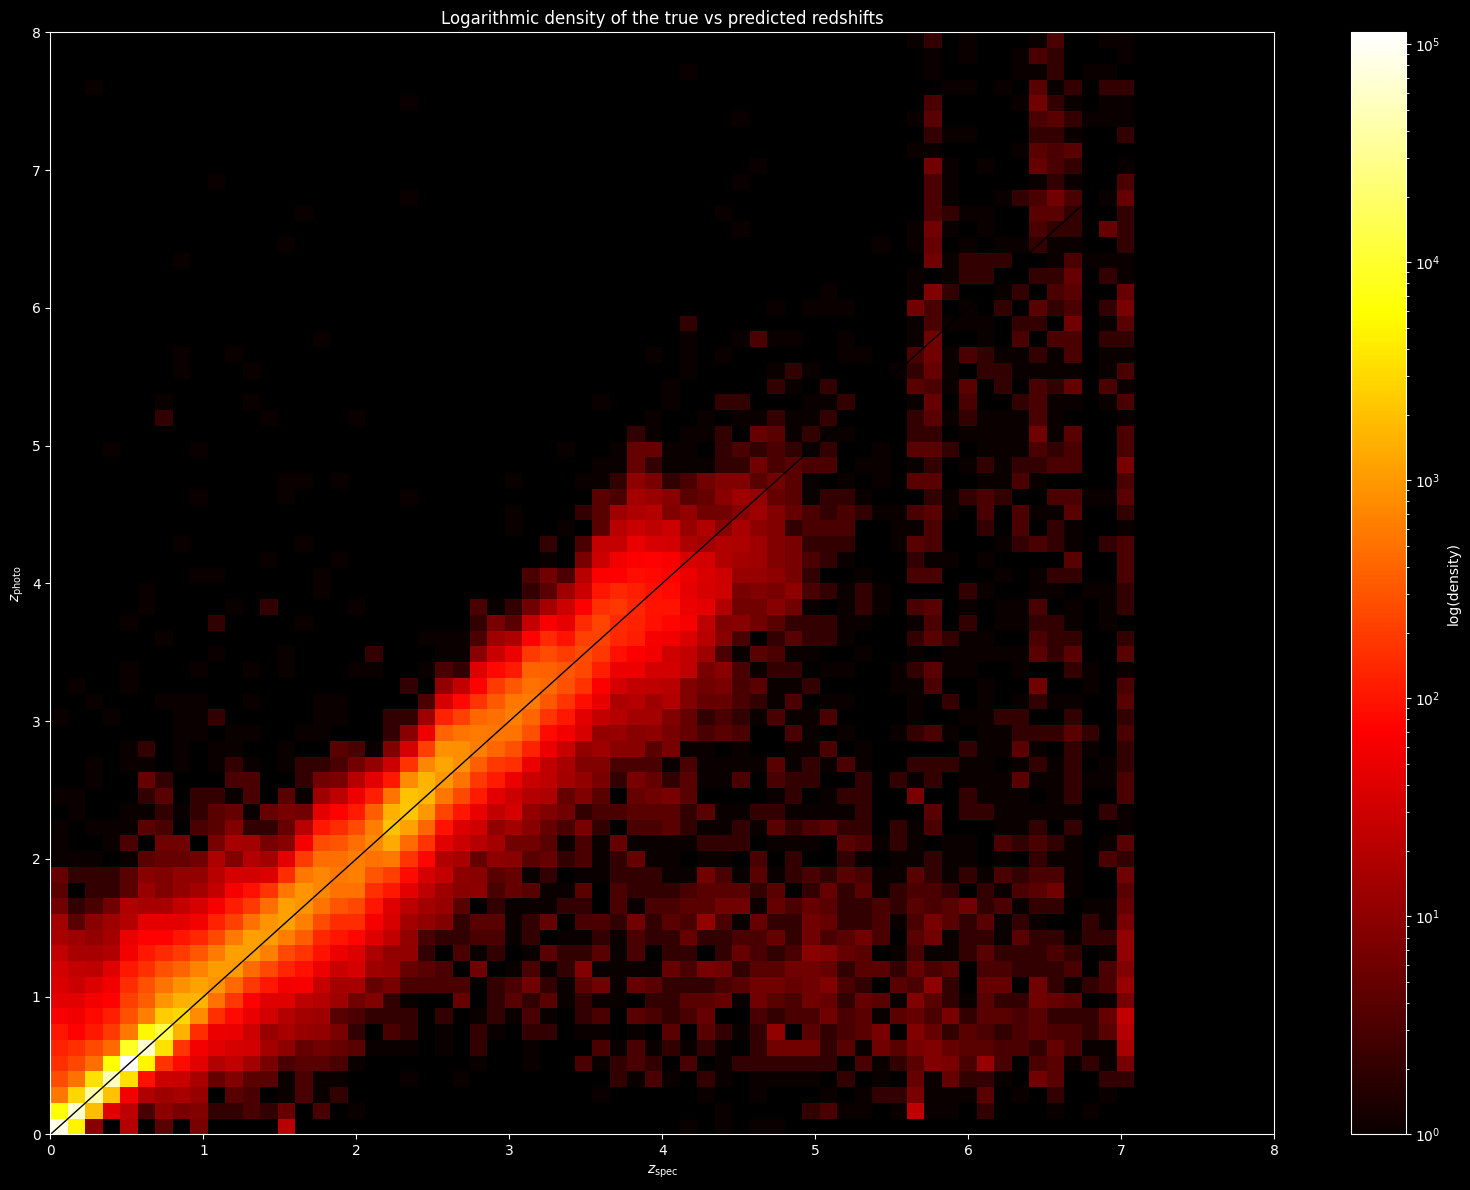

In [7]:
# Mapa de calor de z_real frente a z_predicho éstandar
plt.style.use('dark_background')
x_min, x_max = 0, 8
y_min, y_max = 0, 8
# x_min, x_max = 0, 1
# y_min, y_max = 0, 1
# x_min, x_max = 1, 4
# y_min, y_max = 1, 4
# x_min, x_max = 4, 8
# y_min, y_max = 4, 8
plt.figure(figsize=(16, 12))

# Cálculo del histograma 2D con escala logarítmica
counts, xedges, yedges, im = plt.hist2d(
    y_all,                 # z_spec (redshift "real")
    preds_all,      # z_photo (redshift "predicho")
    bins=70,
    range=[[x_min, x_max], [y_min, y_max]],
    cmap='hot',
    norm=colors.LogNorm()  # Densidad logarítmica
)
cbar = plt.colorbar(im, label='log(density)')

plt.plot([x_min, x_max], [x_min, x_max], color='black', linewidth=1)
plt.xlabel(r'$z_{\mathrm{spec}}$')
plt.ylabel(r'$z_{\mathrm{photo}}$')
plt.title('Logarithmic density of the true vs predicted redshifts')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.tight_layout()
plt.show()

In [8]:
# =============
# EVALUACIÓN Y REPRESENTACIÓN EN BASE A LOS DATOS COMPLETOS DE LA SDSS

from astropy.io import fits
import gc
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np
import os
import pickle
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

del train_dataset, test_dataset, train_loader, test_loader
torch.cuda.empty_cache()
gc.collect()

# Configurar dispositivo para GPU si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Definir la clase del Dataset para tensores (no listas)
class SpectraDataset(Dataset):
    def __init__(self, flux_pt_path, wavelength_pt_path, redshift_pt_path):
        # Cargar los tensores previamente guardados
        self.flux = torch.load(flux_pt_path)         # Tensor de forma (num_samples, num_points)
        self.wavelength = torch.load(wavelength_pt_path)
        self.redshift = torch.load(redshift_pt_path)   # Tensor de forma (num_samples, 1) o (num_samples,)
        
    def __len__(self):
        return self.flux.shape[0]
    
    def __getitem__(self, idx):
        # Combina flux y wavelength en un tensor de entrada de dos canales
        input_sample = torch.stack([self.flux[idx], self.wavelength[idx]], dim=0)  # [2, num_points]
        target = self.redshift[idx]
        return input_sample, target

# Definir el modelo CNN en PyTorch con dropout para regularización
class CNN(nn.Module):
    def __init__(self, num_points):
        super(CNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv1d(in_channels=2, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        # Con 5 capas de max pooling, la dimensión se reduce en un factor de 2^5 = 32
        conv_output_size = num_points // 32
        self.fc_layers = nn.Sequential(
            nn.Linear(256 * conv_output_size, 128),
            nn.ReLU(),
            nn.Dropout(p=0.25),  # Regularización con Dropout
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

num_points = 5000 # Número de puntos en cada espectro
modelCNN = CNN(num_points).to(device)

data_dir  = "data"
storage_dir = "storage"
batch_size = 32 # Parámetro de batch
model_checkpoint = 'storage/modelCNN_UPD6_600ktest.pth' # Ruta del checkpoint del modelo

# Instanciar el modelo y cargar el checkpoint
modelCNN = CNN(num_points).to(device)
checkpoint = torch.load(model_checkpoint, map_location=device)
modelCNN.load_state_dict(checkpoint['model_state_dict'])
modelCNN.eval()


# Evaluación de la primera mitad (Half 1)

# Rutas para la primera mitad
flux_pt_path1       = os.path.join(data_dir, "spectra_data_complete_flux1.pt")
wavelength_pt_path1 = os.path.join(data_dir, "spectra_data_complete_wavelength1.pt")
redshift_pt_path1   = os.path.join(data_dir, "spectra_data_complete_redshift1.pt")

# Crear dataset y dataloader para la primera mitad
dataset1 = SpectraDataset(flux_pt_path1, wavelength_pt_path1, redshift_pt_path1)
dataloader1 = DataLoader(dataset1, batch_size=batch_size, shuffle=False)

predicted1 = []
real1 = []

with torch.no_grad():
    for x_batch, y_batch in dataloader1:
        x_batch = x_batch.to(device)
        preds = modelCNN(x_batch).cpu().numpy()  # forma: (batch_size, 1)
        predicted1.append(preds)
        real1.append(y_batch.numpy())

# Concatenar los resultados de la primera mitad
predicted1 = np.concatenate(predicted1, axis=0)
real1 = np.concatenate(real1, axis=0)

# Guardar los resultados en archivos .npy
np.save(os.path.join(storage_dir, "predicted1_6.npy"), predicted1)
np.save(os.path.join(storage_dir, "real1_6.npy"), real1)

print("Evaluación de la primera mitad completada y resultados guardados.")

# Liberar memoria
del dataset1, dataloader1
torch.cuda.empty_cache()
gc.collect()


# Evaluación de la segunda mitad (Half 2)

# Rutas para la segunda mitad
flux_pt_path2       = os.path.join(data_dir, "spectra_data_complete_flux2.pt")
wavelength_pt_path2 = os.path.join(data_dir, "spectra_data_complete_wavelength2.pt")
redshift_pt_path2   = os.path.join(data_dir, "spectra_data_complete_redshift2.pt")

# Crear dataset y dataloader para la segunda mitad
dataset2 = SpectraDataset(flux_pt_path2, wavelength_pt_path2, redshift_pt_path2)
dataloader2 = DataLoader(dataset2, batch_size=batch_size, shuffle=False)

predicted2 = []
real2 = []

with torch.no_grad():
    for x_batch, y_batch in dataloader2:
        x_batch = x_batch.to(device)
        preds = modelCNN(x_batch).cpu().numpy()
        predicted2.append(preds)
        real2.append(y_batch.numpy())

# Concatenar los resultados de la segunda mitad
predicted2 = np.concatenate(predicted2, axis=0)
real2 = np.concatenate(real2, axis=0)

# Guardar los resultados en archivos .npy
np.save(os.path.join(storage_dir, "predicted2_6.npy"), predicted2)
np.save(os.path.join(storage_dir, "real2_6.npy"), real2)

print("Evaluación de la segunda mitad completada y resultados guardados.")

# Liberar memoria
del dataset2, dataloader2
torch.cuda.empty_cache()
gc.collect()


# Cargar resultados y calcular correlación

# Cargar los datos guardados
predicted1 = np.load(os.path.join(storage_dir, "predicted1_6.npy"))
real1      = np.load(os.path.join(storage_dir, "real1_6.npy"))
predicted2 = np.load(os.path.join(storage_dir, "predicted2_6.npy"))
real2      = np.load(os.path.join(storage_dir, "real2_6.npy"))

# Concatenar ambos resultados
ypredicted = np.concatenate([predicted1, predicted2], axis=0)
yreal      = np.concatenate([real1, real2], axis=0)

# Asegurarse de que ambos sean vectores 1D
ypredicted = ypredicted.squeeze()     # Ahora tiene forma (N,)
yreal      = yreal.squeeze()          # Ahora tiene forma (N,)

# Calcular la correlación lineal
correlation = np.corrcoef(yreal, ypredicted)[0, 1]

print(f"Correlación lineal: {correlation:.4f}")
print(f"Número de muestras evaluadas: {len(yreal)}")

Usando dispositivo: cuda
Evaluación de la primera mitad completada y resultados guardados.
Evaluación de la segunda mitad completada y resultados guardados.
Correlación lineal: 0.0203
Número de muestras evaluadas: 3372890


c:\Users\alfa\anaconda3\envs\TFGF\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


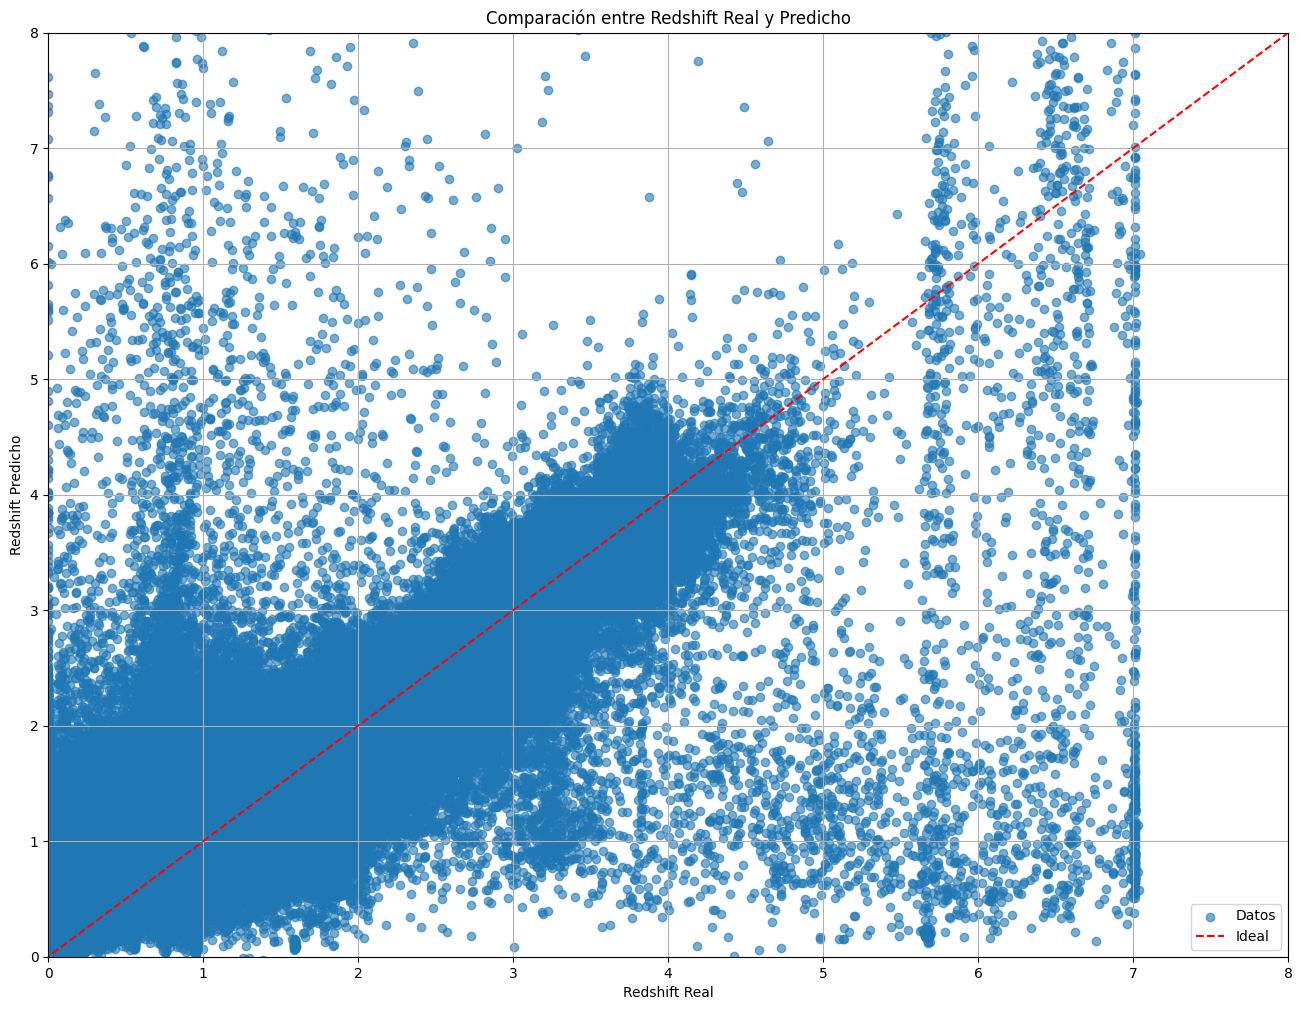

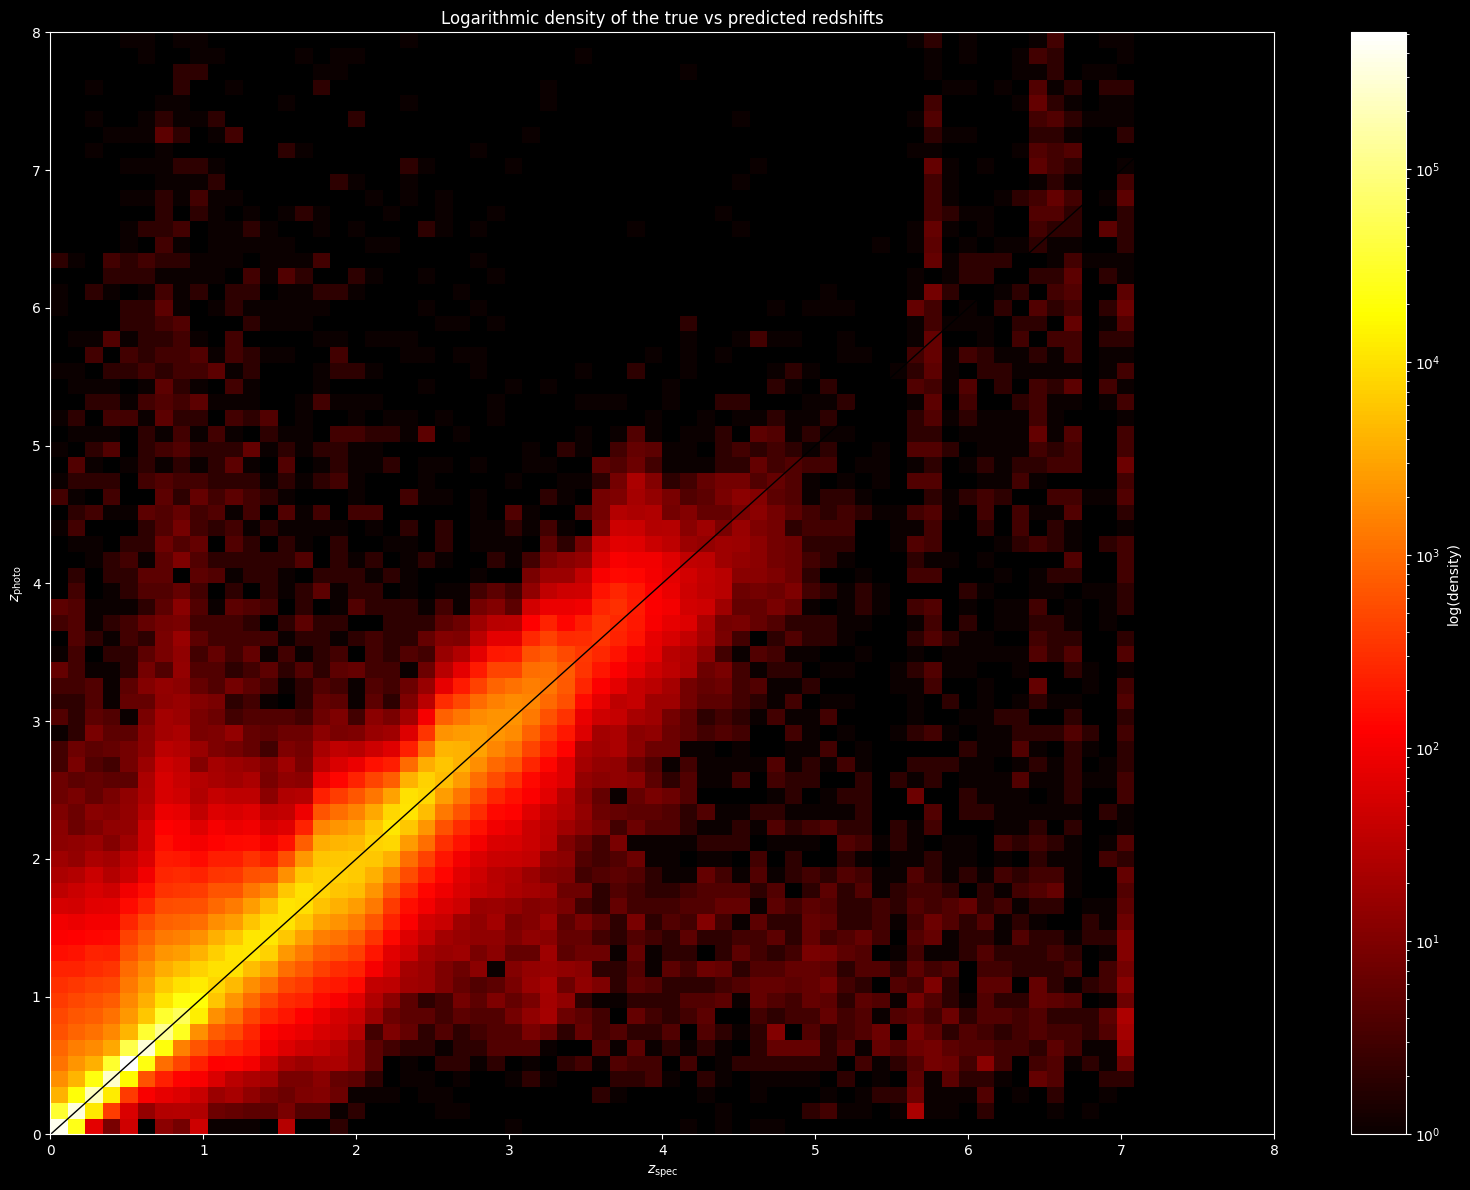

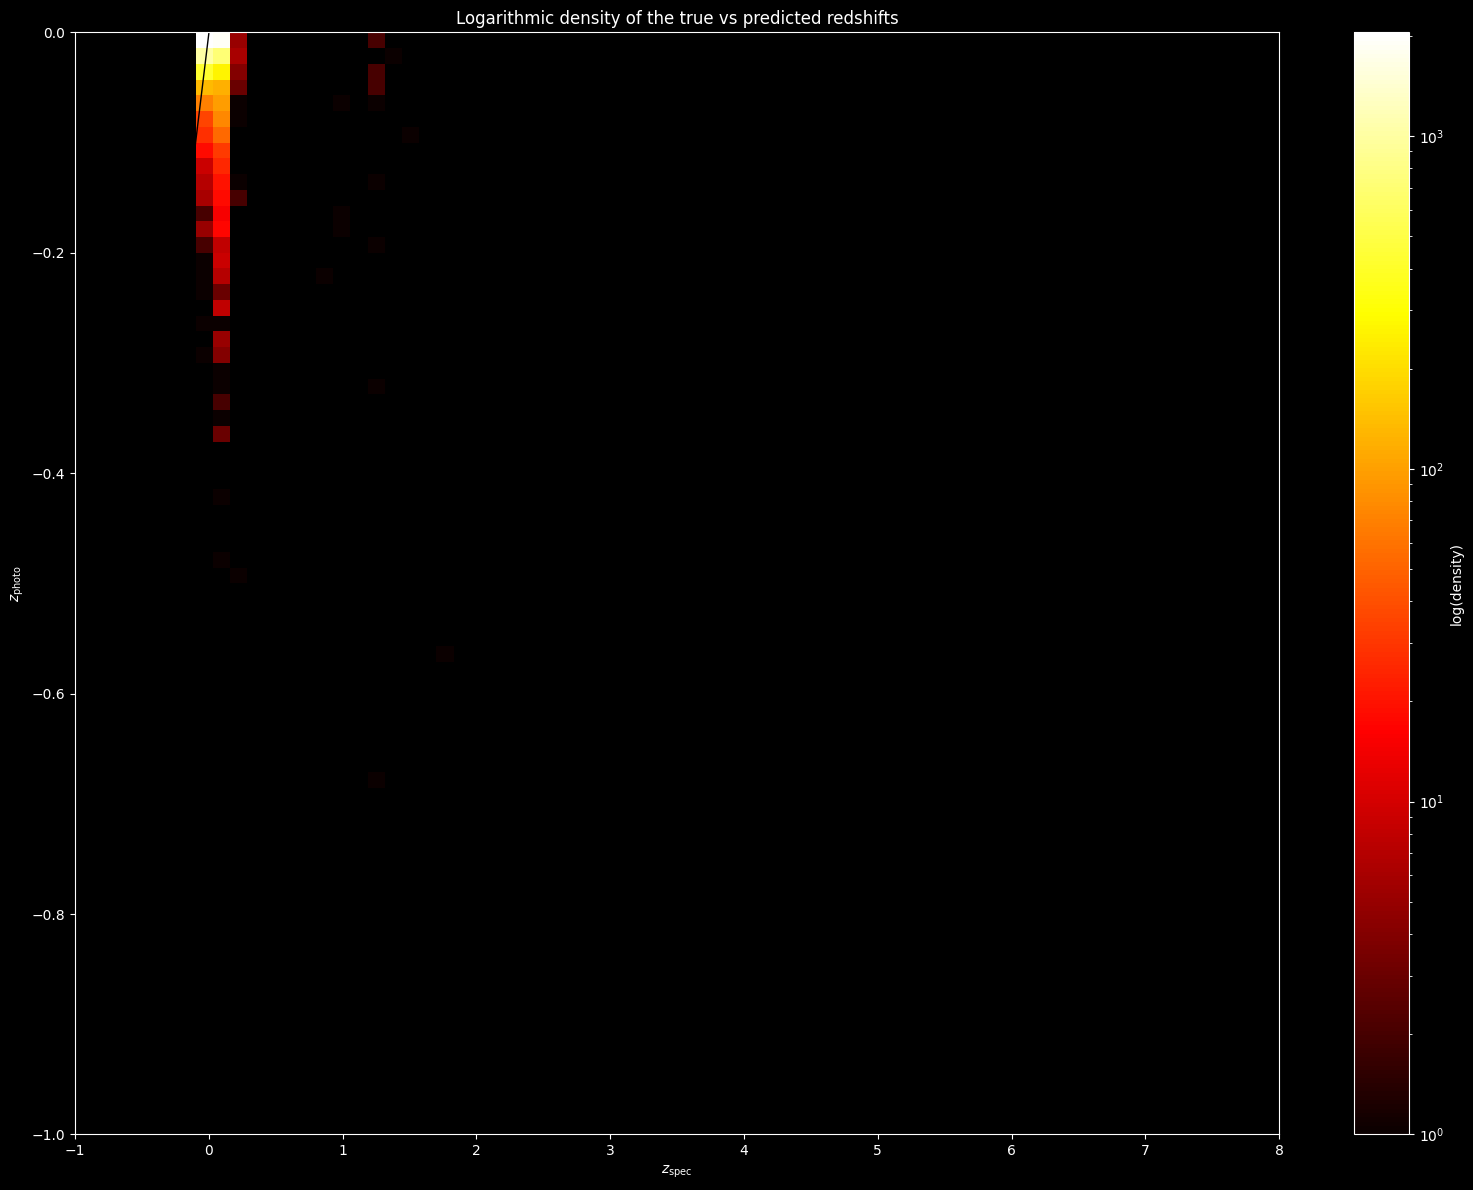

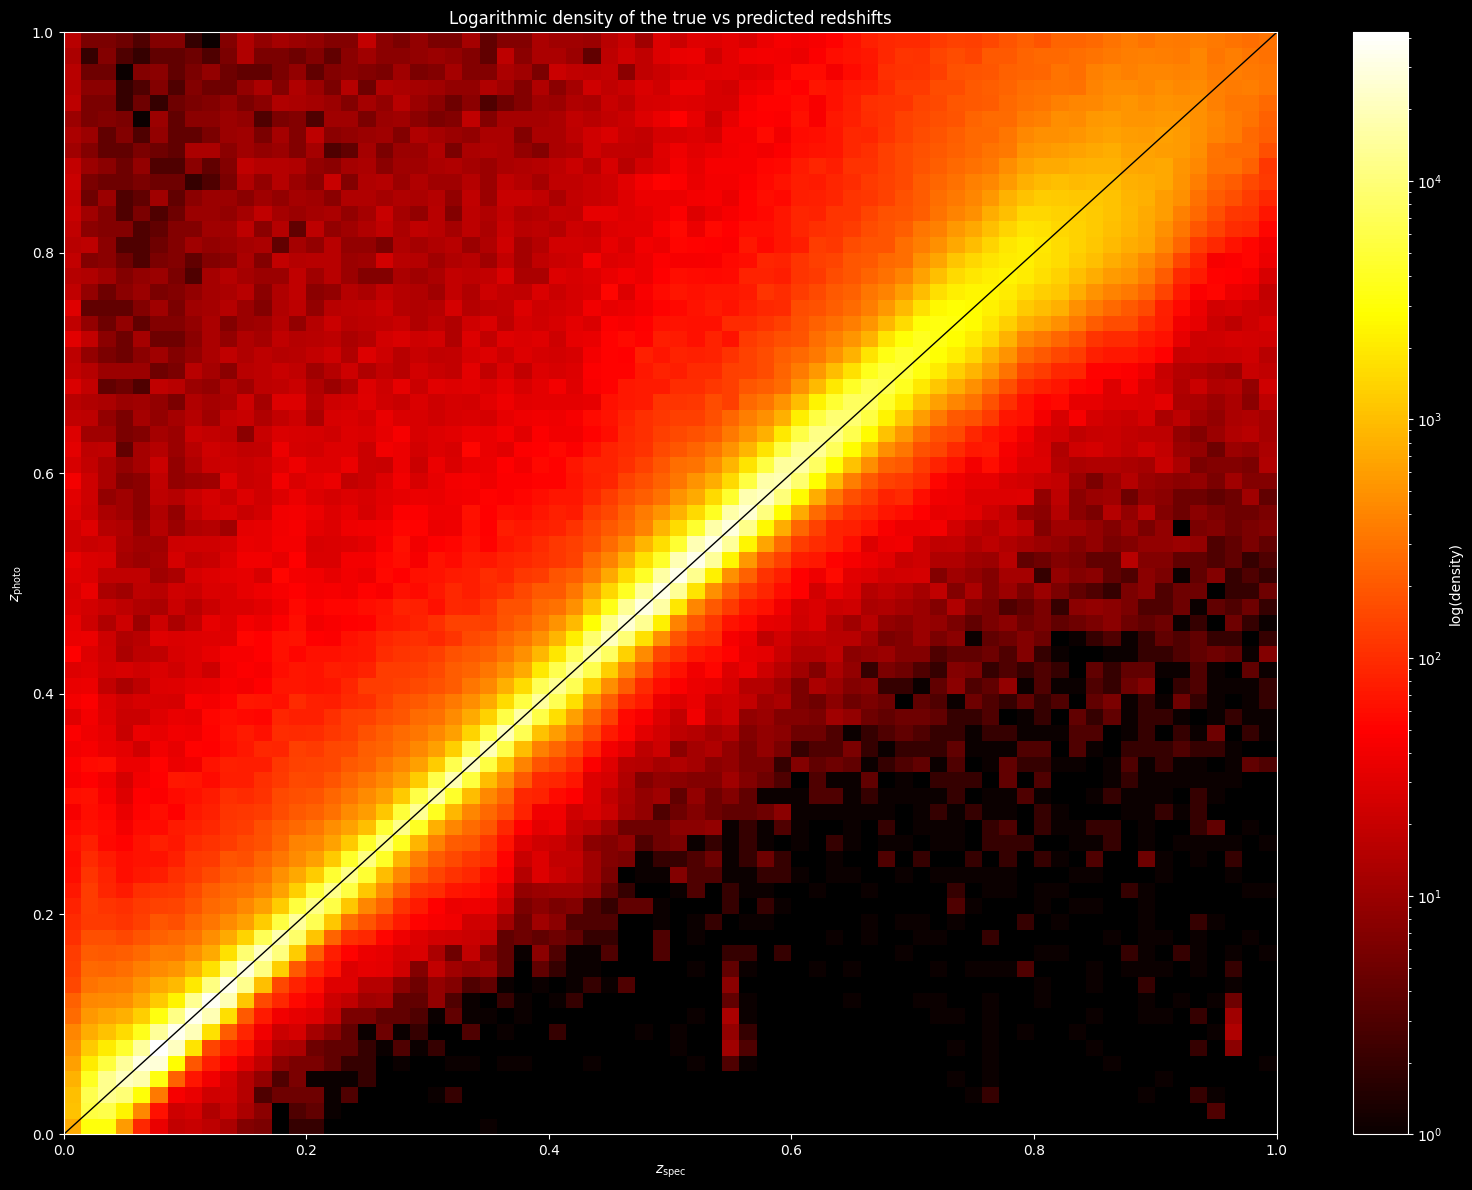

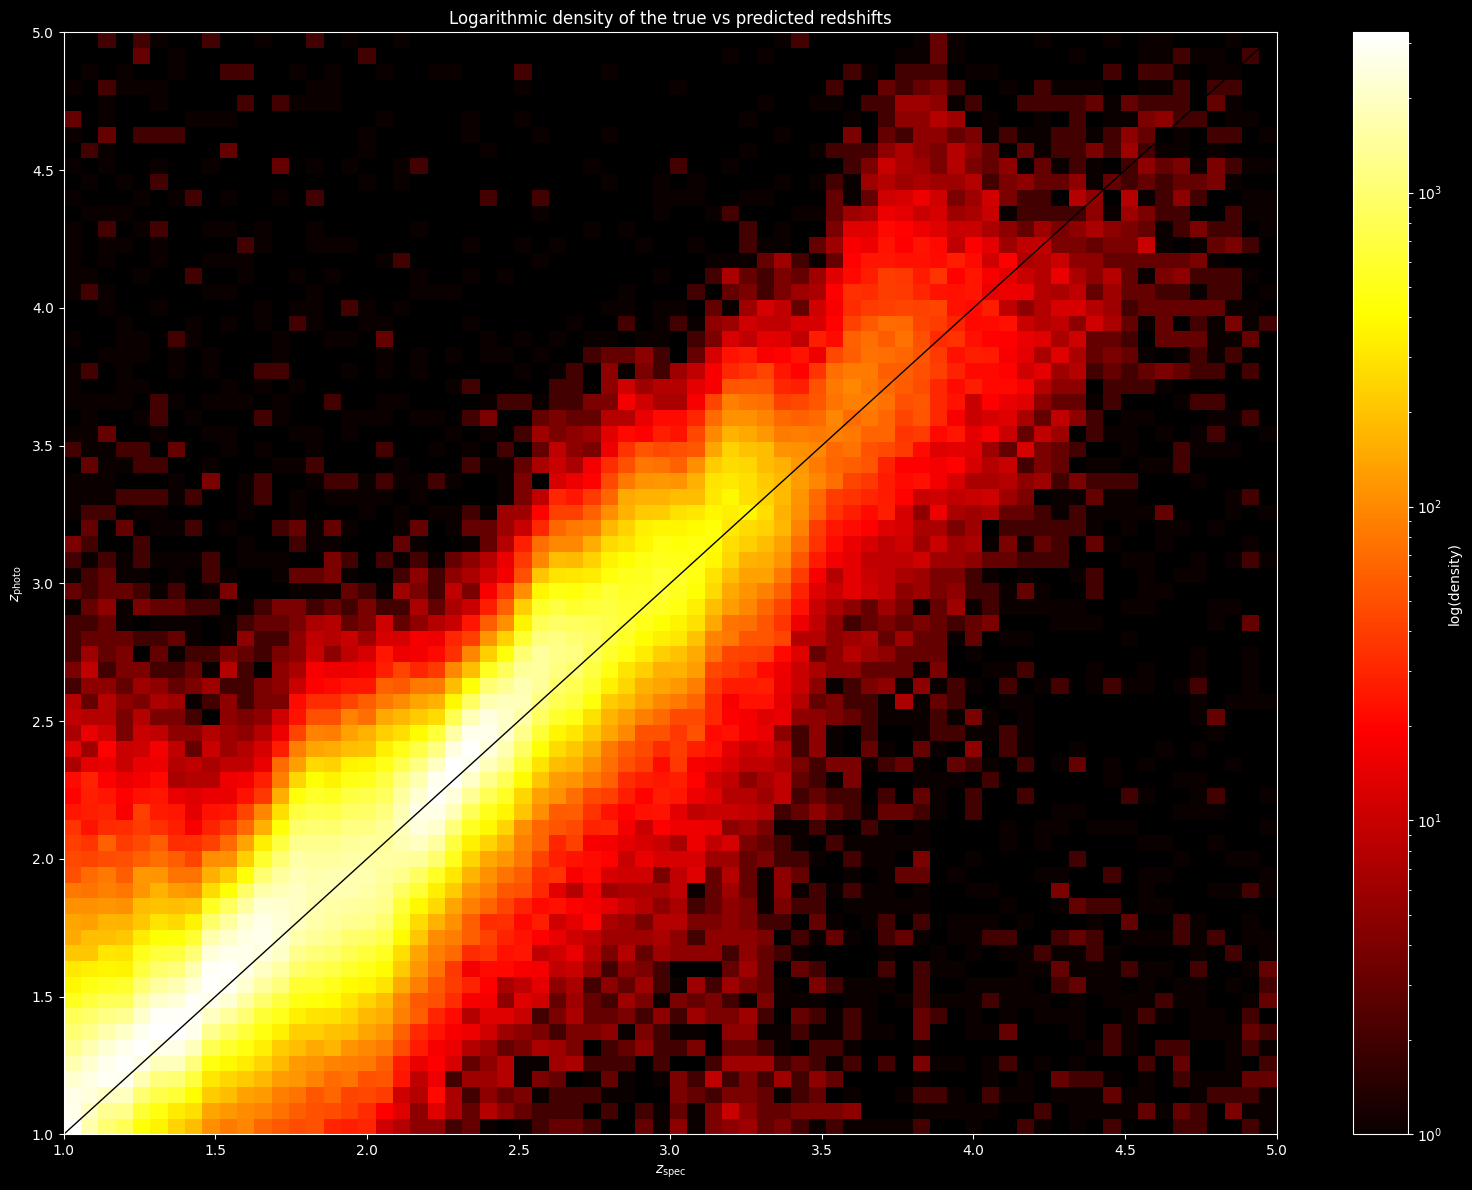

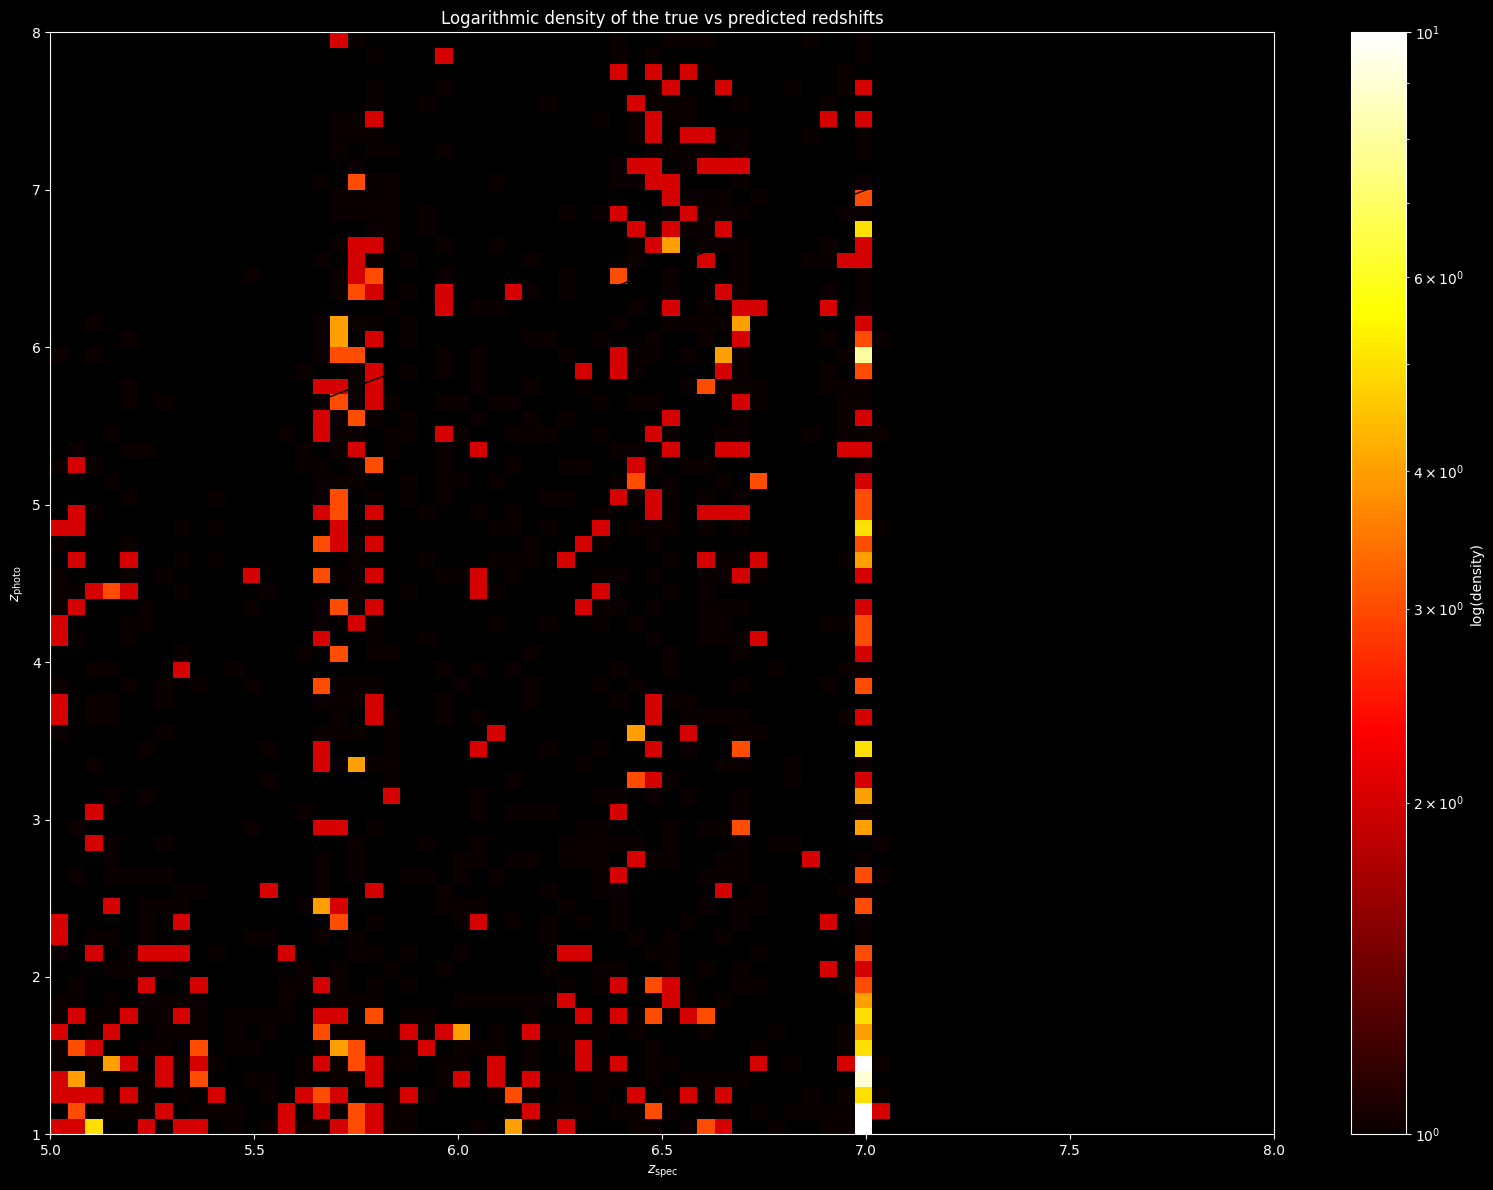

In [9]:
# Dispersión de puntos de z_real frente a z_predicho

plt.rcdefaults()
plt.figure(figsize=(16, 12))
plt.scatter(yreal, ypredicted, alpha=0.6, label='Datos')
plt.xlabel('Redshift Real')
plt.ylabel('Redshift Predicho')
plt.title('Comparación entre Redshift Real y Predicho')
# Añadir la línea ideal (y=x)
min_val = min(yreal.min(), ypredicted.min())
max_val = max(yreal.max(), ypredicted.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal')
plt.legend()
plt.grid(True)
plt.xlim(0, 8)
plt.ylim(0, 8)
plt.show()






# Mapa de calor de z_real frente a z_predicho éstandar

plt.style.use('dark_background')

x_min, x_max = 0, 8
y_min, y_max = 0, 8

plt.figure(figsize=(16, 12))

# Cálculo del histograma 2D con escala logarítmica
counts, xedges, yedges, im = plt.hist2d(
    yreal,                 # z_spec (redshift "real")
    ypredicted,      # z_photo (redshift "predicho")
    bins=70,
    range=[[x_min, x_max], [y_min, y_max]],
    cmap='hot',
    norm=colors.LogNorm()  # Densidad logarítmica
)

cbar = plt.colorbar(im, label='log(density)')

plt.plot([x_min, x_max], [x_min, x_max], color='black', linewidth=1)
plt.xlabel(r'$z_{\mathrm{spec}}$')
plt.ylabel(r'$z_{\mathrm{photo}}$')
plt.title('Logarithmic density of the true vs predicted redshifts')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.tight_layout()
plt.show()






# Mapa de calor de z_real frente a z_predicho para comprobar negatividad

plt.style.use('dark_background')

x_min, x_max = -1, 8
y_min, y_max = -1, 0

plt.figure(figsize=(16, 12))

# Cálculo del histograma 2D con escala logarítmica
counts, xedges, yedges, im = plt.hist2d(
    yreal,                 # z_spec (redshift "real")
    ypredicted,      # z_photo (redshift "predicho")
    bins=70,
    range=[[x_min, x_max], [y_min, y_max]],
    cmap='hot',
    norm=colors.LogNorm()  # Densidad logarítmica
)

cbar = plt.colorbar(im, label='log(density)')

plt.plot([x_min, x_max], [x_min, x_max], color='black', linewidth=1)
plt.xlabel(r'$z_{\mathrm{spec}}$')
plt.ylabel(r'$z_{\mathrm{photo}}$')
plt.title('Logarithmic density of the true vs predicted redshifts')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.tight_layout()
plt.show()






# Mapa de calor de z_real frente a z_predicho para comprobar rangos bajos

plt.style.use('dark_background')

x_min, x_max = 0, 1
y_min, y_max = 0, 1

plt.figure(figsize=(16, 12))

# Cálculo del histograma 2D con escala logarítmica
counts, xedges, yedges, im = plt.hist2d(
    yreal,                 # z_spec (redshift "real")
    ypredicted,      # z_photo (redshift "predicho")
    bins=70,
    range=[[x_min, x_max], [y_min, y_max]],
    cmap='hot',
    norm=colors.LogNorm()  # Densidad logarítmica
)

cbar = plt.colorbar(im, label='log(density)')

plt.plot([x_min, x_max], [x_min, x_max], color='black', linewidth=1)
plt.xlabel(r'$z_{\mathrm{spec}}$')
plt.ylabel(r'$z_{\mathrm{photo}}$')
plt.title('Logarithmic density of the true vs predicted redshifts')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.tight_layout()
plt.show()






# Mapa de calor de z_real frente a z_predicho para comprobar rangos intermedios

plt.style.use('dark_background')

x_min, x_max = 1, 5
y_min, y_max = 1, 5

plt.figure(figsize=(16, 12))

# Cálculo del histograma 2D con escala logarítmica
counts, xedges, yedges, im = plt.hist2d(
    yreal,                 # z_spec (redshift "real")
    ypredicted,      # z_photo (redshift "predicho")
    bins=70,
    range=[[x_min, x_max], [y_min, y_max]],
    cmap='hot',
    norm=colors.LogNorm()  # Densidad logarítmica
)

cbar = plt.colorbar(im, label='log(density)')

plt.plot([x_min, x_max], [x_min, x_max], color='black', linewidth=1)
plt.xlabel(r'$z_{\mathrm{spec}}$')
plt.ylabel(r'$z_{\mathrm{photo}}$')
plt.title('Logarithmic density of the true vs predicted redshifts')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.tight_layout()
plt.show()







# Mapa de calor de z_real frente a z_predicho para comprobar rangos altos

plt.style.use('dark_background')

x_min, x_max = 5, 8
y_min, y_max = 1, 8

plt.figure(figsize=(16, 12))

# Cálculo del histograma 2D con escala logarítmica
counts, xedges, yedges, im = plt.hist2d(
    yreal,                 # z_spec (redshift "real")
    ypredicted,      # z_photo (redshift "predicho")
    bins=70,
    range=[[x_min, x_max], [y_min, y_max]],
    cmap='hot',
    norm=colors.LogNorm()  # Densidad logarítmica
)

cbar = plt.colorbar(im, label='log(density)')

plt.plot([x_min, x_max], [x_min, x_max], color='black', linewidth=1)
plt.xlabel(r'$z_{\mathrm{spec}}$')
plt.ylabel(r'$z_{\mathrm{photo}}$')
plt.title('Logarithmic density of the true vs predicted redshifts')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.tight_layout()
plt.show()

Redshift real: 0.082088366
Redshift predicho: 0.08604121208190918


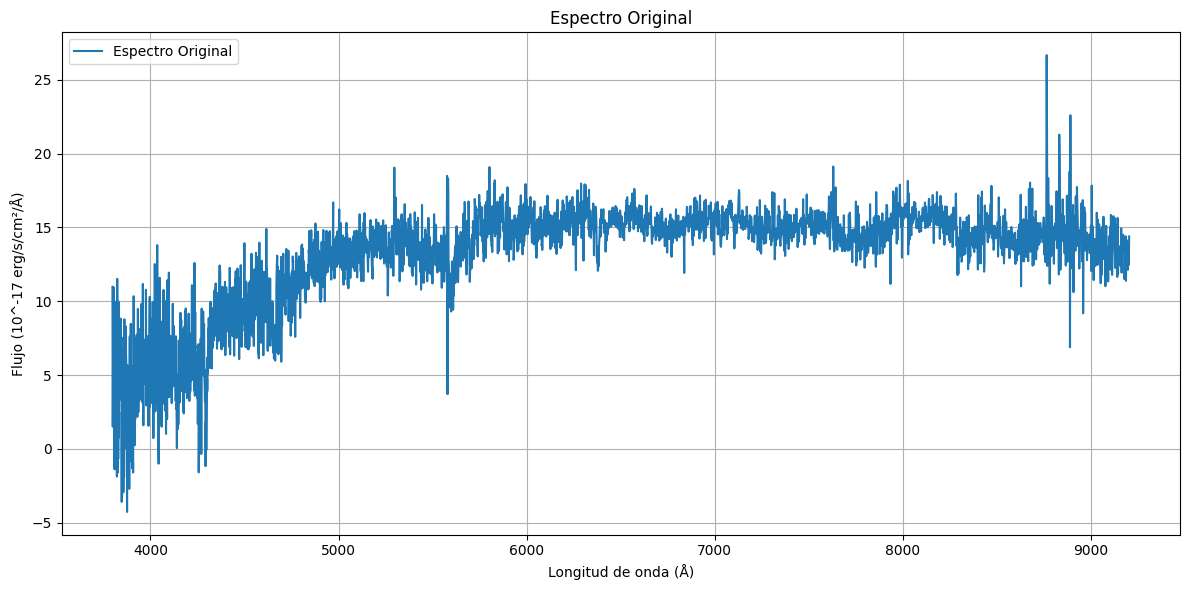

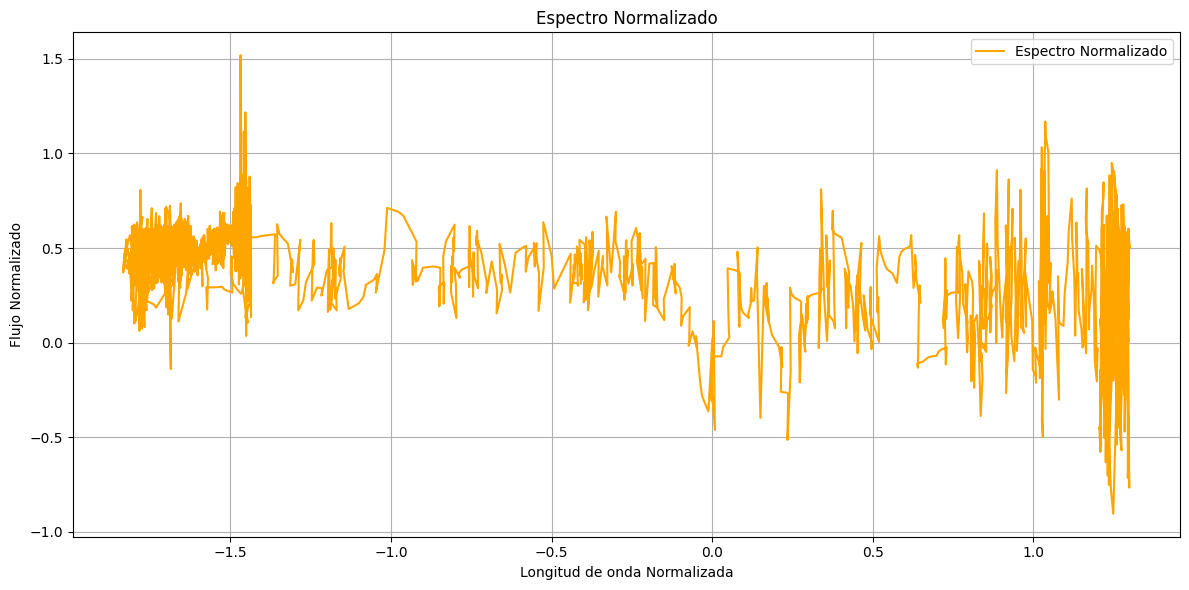

In [10]:
# Obtener la lista inicial de archivos FITS
folder_path = r'spectrums'
files = [f for f in os.listdir(folder_path) if f.endswith('.fits')]
files = random.sample(files, len(files))
file_path = os.path.join(folder_path, files[0])

# Cargar el checkpoint del modelo y los escaladores
checkpoint = torch.load('storage/modelCNN_UPD6_600ktest.pth', map_location=device)
modelCNN.load_state_dict(checkpoint['model_state_dict'])
modelCNN.eval()

# Los escaladores se encuentran en un diccionario con las claves "flux_scaler" y "wavelength_scaler"
with open('extra/scaler_600k_fitted.pkl', 'rb') as f:
    scaler_dict = pickle.load(f)
flux_scaler = scaler_dict["flux_scaler"]
wavelength_scaler = scaler_dict["wavelength_scaler"]

# Abrir el archivo FITS y extraer datos
with fits.open(file_path) as hdul:
    test_flux = hdul[1].data["flux"]
    test_loglam = hdul[1].data["loglam"]
    test_redshift = hdul[2].data["Z"][0]

# Convertir loglam a wavelength
test_wavelength = 10 ** test_loglam

def expand_points(wavelength, flux, target_count=5000):
    # Convertir a listas para facilitar las inserciones
    wl = list(wavelength)
    fl = list(flux)
    
    # Calcular las diferencias absolutas entre puntos consecutivos
    diffs = [abs(fl[i+1] - fl[i]) for i in range(len(fl)-1)]
    # Obtener los índices ordenados de mayor a menor diferencia
    sorted_indices = sorted(range(len(diffs)), key=lambda i: diffs[i], reverse=True)
    
    # Insertar nuevos puntos utilizando los índices ordenados
    while len(wl) < target_count:
        # Se recorre la lista de índices en orden descendente para evitar problemas con el reordenamiento
        for idx in sorted_indices:
            if len(wl) >= target_count:
                break
            # Calcular la interpolación lineal entre el punto idx y el siguiente
            new_wl = (wl[idx] + wl[idx+1]) / 2
            new_fl = (fl[idx] + fl[idx+1]) / 2
            # Insertar el nuevo punto en la posición correspondiente
            wl.insert(idx+1, new_wl)
            fl.insert(idx+1, new_fl)
    
    return np.array(wl), np.array(fl)

# Asegurarse de tener exactamente num_points
test_wavelength, test_flux = expand_points(test_wavelength, test_flux, target_count=num_points)

# Preprocesamiento para el modelo
# El modelo espera dos canales: canal 0 -> flux y canal 1 -> wavelength.
# Separamos cada canal y aplicamos el escalador correspondiente.
# Cada escalador fue ajustado en datos de forma (n_samples, 5000)

# Redimensionar cada canal para que tenga forma (1, num_points)
input_flux = test_flux.reshape(1, -1)              # (1, 5000)
input_wavelength = test_wavelength.reshape(1, -1)  # (1, 5000)

# Aplicar la normalización con los escaladores correspondientes
flux_scaled = flux_scaler.transform(input_flux)                     # (1, 5000)
wavelength_scaled = wavelength_scaler.transform(input_wavelength)   # (1, 5000)

# Reconstruir el input con dos canales: (2, 5000) y agregar dimensión de batch => (1, 2, 5000)
input_scaled = np.stack([flux_scaled[0], wavelength_scaled[0]], axis=0)
input_scaled = input_scaled.reshape(1, 2, num_points)

# Convertir a tensor (usando torch.from_numpy para no saturar la memoria)
input_tensor = torch.from_numpy(input_scaled).to(device)

# Evaluación del modelo
with torch.no_grad():
    predicted_redshift = modelCNN(input_tensor)

plt.rcdefaults()
print("Redshift real:", test_redshift)
print("Redshift predicho:", predicted_redshift.item())

# Representación de espectros
plt.figure(figsize=(12, 6))
plt.plot(test_wavelength, test_flux, label="Espectro Original")
plt.xlabel("Longitud de onda (Å)")
plt.ylabel("Flujo (10^-17 erg/s/cm²/Å)")
plt.title("Espectro Original")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(wavelength_scaled.flatten(), flux_scaled.flatten(), label="Espectro Normalizado", color="orange")
plt.xlabel("Longitud de onda Normalizada")
plt.ylabel("Flujo Normalizado")
plt.title("Espectro Normalizado")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()